# **✨ Image Colorization Using U-Net + Residual Blocks**

## **📌 Introduction**
Color has the power to transform grayscale images into vibrant, lively visuals. In this notebook, we build a **deep learning–based image colorization model** using a **U-Net architecture enhanced with Residual Blocks**. This powerful combination helps the model capture fine details, maintain structure, and generate realistic colors. ✨

## **🎯 What You Will Learn**
- ✔️ Convert RGB images to grayscale  
- ✔️ Prepare paired datasets for colorization  
- ✔️ Understand how U-Net works for image-to-image tasks  
- ✔️ Learn how Residual Blocks improve gradient flow  
- ✔️ Train a model to predict natural-looking colors  

## **🧠 Why This Project Is Interesting**
Image colorization is a visually engaging and highly practical deep learning task. It is used in:  
- 🎞️ Restoring old black-and-white movies  
- 🖼️ Colorizing historical photos  
- 📰 Enhancing training data for CV tasks  
- 🎨 Creative digital art and VFX  

Its visual nature makes it perfect for learning and for presenting on Kaggle.

## **🚀 What We Will Build**
- A **U-Net model** for feature extraction  
- **Residual Blocks** for deeper learning  
- Training pipeline using CIFAR-10  
- 📉 Loss curve visualization  
- 🖼️ Grayscale vs Predicted vs Original comparison  
- 🔳 A collage of colorized results  

Let’s bring grayscale images to life with deep learning! 🌟

# **📌 Imports**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses
import numpy as np
import matplotlib.pyplot as plt
import random


import warnings
warnings.filterwarnings('ignore')


if tf.test.is_gpu_available():
    print("GPU is active!")
else:
    print("GPU not found.")

2026-01-30 18:05:14.675183: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769796315.115824      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769796315.248866      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769796316.363168      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769796316.363215      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769796316.363218      55 computation_placer.cc:177] computation placer alr

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU is active!


I0000 00:00:1769796336.682286      55 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769796336.689311      55 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# **📌 Load CIFAR-10 Dataset & Convert to Grayscale**

In [5]:
# Load CIFAR-10
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Convert to grayscale
x_train_gray = tf.image.rgb_to_grayscale(x_train)
x_test_gray  = tf.image.rgb_to_grayscale(x_test)

print("Train grayscale shape:", x_train_gray.shape)
print("Train color shape:", x_train.shape)

Train grayscale shape: (50000, 32, 32, 1)
Train color shape: (50000, 32, 32, 3)


# **📌 Build Residual Block**

In [6]:
def residual_block(x, filters):
    shortcut = x

    # If shortcut has different channels → use 1×1 conv to match
    if x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same")(shortcut)

    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

# **📌 Build U-Net + Residual Blocks**

In [7]:
def build_unet(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = residual_block(inputs, 64)
    p1 = layers.MaxPooling2D()(c1)

    c2 = residual_block(p1, 128)
    p2 = layers.MaxPooling2D()(c2)

    c3 = residual_block(p2, 256)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    bn = residual_block(p3, 512)

    # Decoder
    u1 = layers.UpSampling2D()(bn)
    u1 = layers.Concatenate()([u1, c3])
    c4 = residual_block(u1, 256)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = residual_block(u2, 128)

    u3 = layers.UpSampling2D()(c5)
    u3 = layers.Concatenate()([u3, c1])
    c6 = residual_block(u3, 64)

    outputs = layers.Conv2D(3, 1, padding="same", activation="sigmoid")(c6)

    return models.Model(inputs, outputs)

model = build_unet((32, 32, 1))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │        128 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 32,    │          0 │ conv2d_6[0][0],   │
│                     │ 64)               │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ add_2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │      8,320 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 16, 16,    │          0 │ conv2d_9[0][0],   │
│                     │ 128)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 16, 16,    │          0 │ add_3[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 128) │          0 │ re_lu_2[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 8, 8, 256) │    590,080 │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 8, 8, 256) │     33,024 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 8, 8, 256) │          0 │ conv2d_12[0][0],  │
│                     │                   │            │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 8, 8, 256) │          0 │ add_4[0][0]     

 Total params: 8,213,443 (31.33 MB)

 Trainable params: 8,213,443 (31.33 MB)

 Non-trainable params: 0 (0.00 B)

# **📌 Compile the Model**

In [8]:
model.compile(
    optimizer="adam",
    loss="mse"
)

# **📌 Train the Model**

In [9]:
history = model.fit(
    x_train_gray,
    x_train,
    validation_data=(x_test_gray, x_test),
    epochs=30,
    batch_size=64
)

Epoch 1/30


I0000 00:00:1769796474.993535     146 service.cc:152] XLA service 0x7dd8e4002330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769796474.993574     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769796474.993580     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769796476.204783     146 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/782 ━━━━━━━━━━━━━━━━━━━━ 1:12 93ms/step - loss: 0.0707  

I0000 00:00:1769796489.133341     146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 87ms/step - loss: 0.0118 - val_loss: 0.0054
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - loss: 0.0055 - val_loss: 0.0053
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - loss: 0.0051 - val_loss: 0.0051
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - loss: 0.0051 - val_loss: 0.0051
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - loss: 0.0050 - val_loss: 0.0051
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - loss: 0.0047 - val_loss: 0.0052
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - loss: 0.0047 - val_loss: 0.0049
Epoch 9/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - loss: 0.0045 - val_loss: 0.0050
Epoch 10/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - loss: 0.0044 - val_loss: 0.0049
Epoch 11/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - loss: 0.0041 - val_loss: 0.0050
Epoch 12/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 

# **📌 Plot Training Loss Curve**

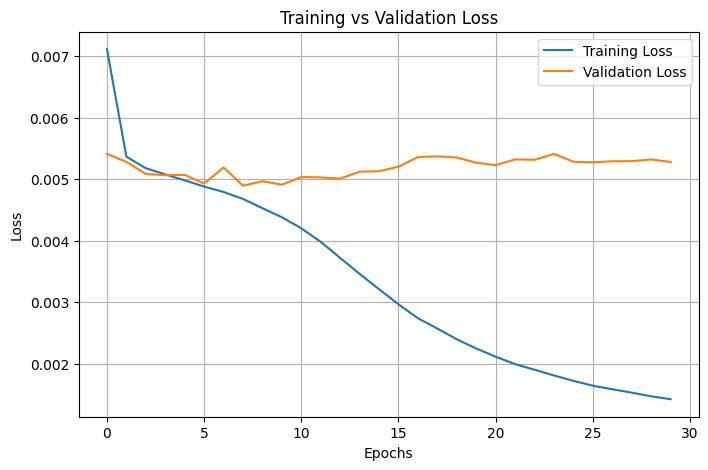

In [10]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# **📌 Predict and Visualize a Few Results**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


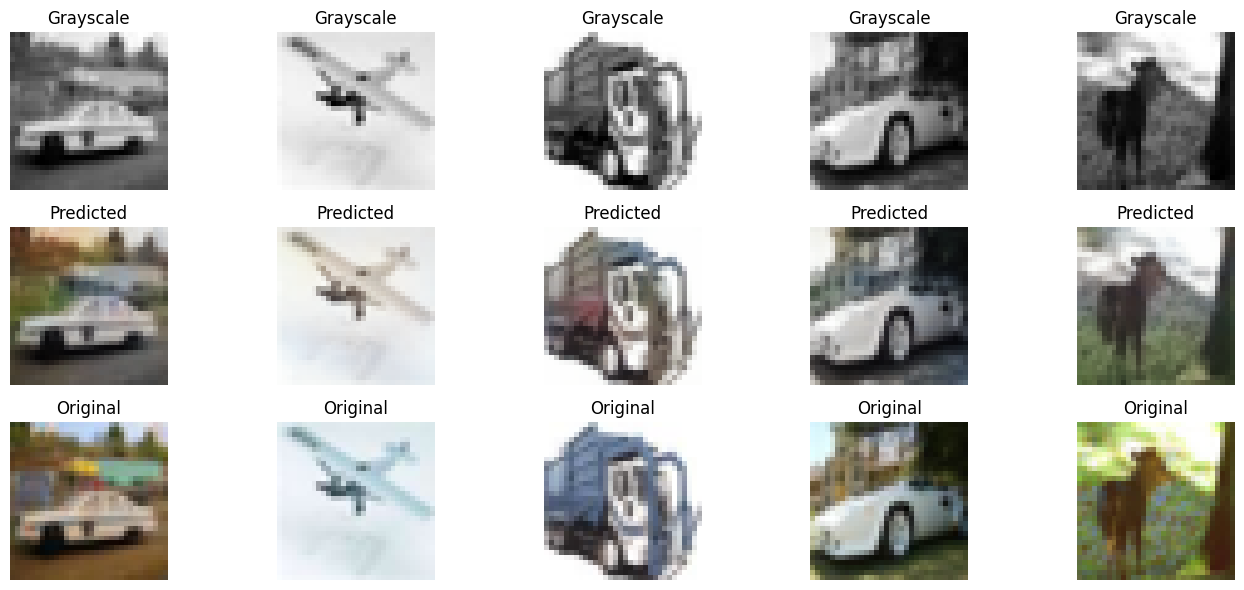

In [12]:
def show_results(n=5):
    indices = random.sample(range(len(x_test)), n)

    plt.figure(figsize=(14, 6))
    for i, idx in enumerate(indices):

        # Convert tensors to numpy
        gray = x_test_gray[idx].numpy() if tf.is_tensor(x_test_gray[idx]) else x_test_gray[idx]
        original = x_test[idx].numpy() if tf.is_tensor(x_test[idx]) else x_test[idx]

        # Predict (model input must be float32)
        color_pred = model.predict(gray[np.newaxis, ...])[0]

        # Plot grayscale
        plt.subplot(3, n, i+1)
        plt.imshow(gray.squeeze(), cmap="gray")
        plt.title("Grayscale")
        plt.axis("off")

        # Plot predicted color
        plt.subplot(3, n, i+n+1)
        plt.imshow(color_pred)
        plt.title("Predicted")
        plt.axis("off")

        # Plot original color
        plt.subplot(3, n, i+2*n+1)
        plt.imshow(original)
        plt.title("Original")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_results(5)

# **📌 Generate a Colorized Collage (16 Samples)**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


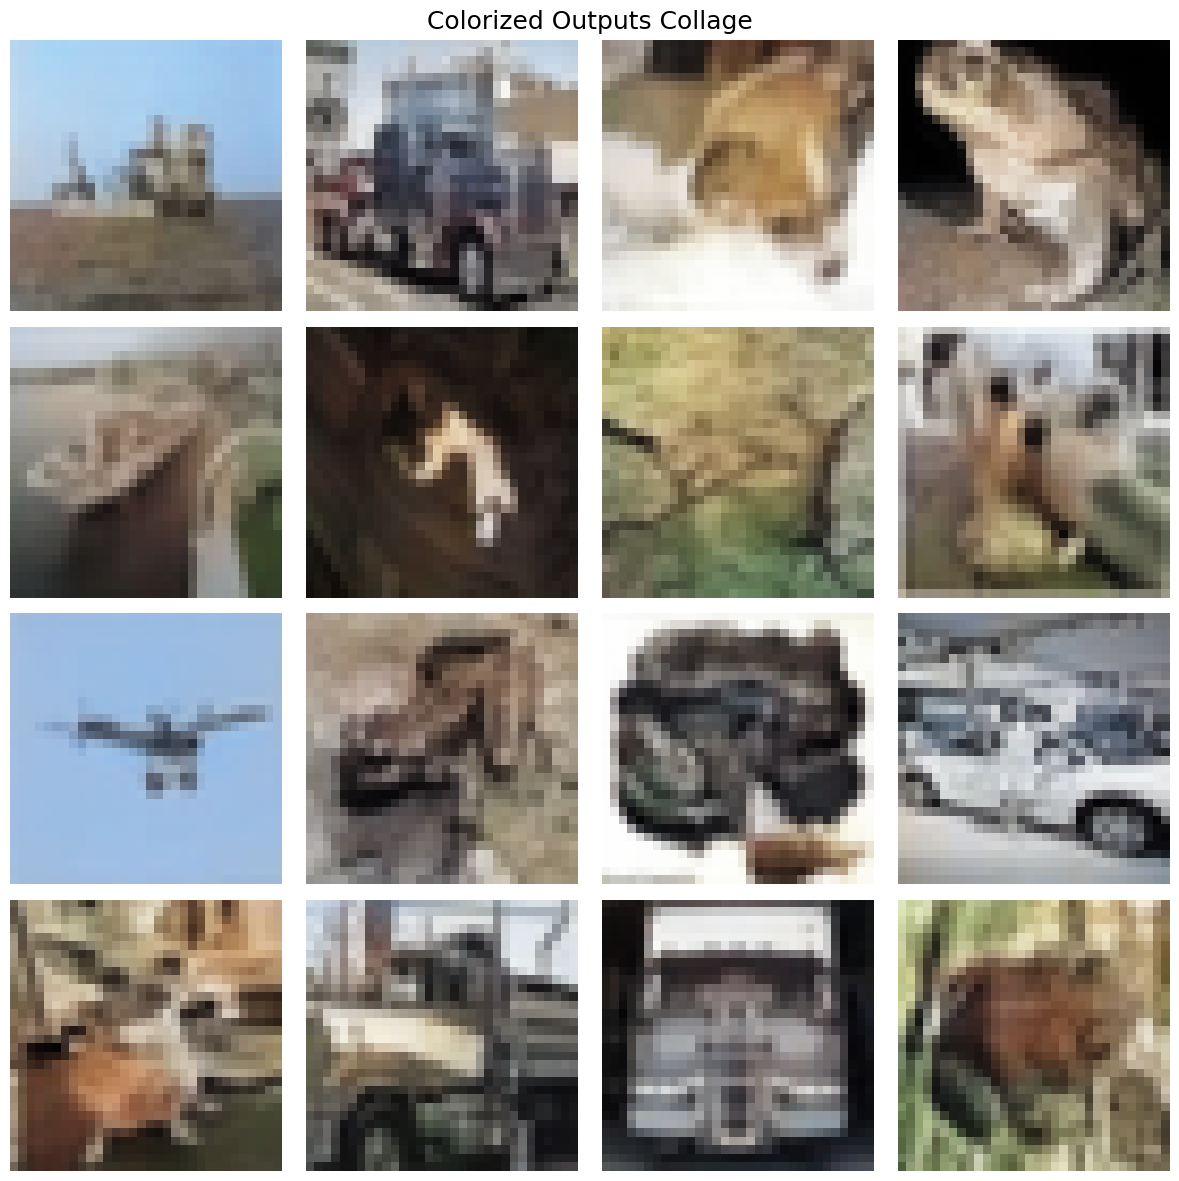

In [13]:
def collage(n=16):
    indices = random.sample(range(len(x_test)), n)

    plt.figure(figsize=(12,12))

    for i, idx in enumerate(indices):
        gray = x_test_gray[idx]
        pred = model.predict(gray[np.newaxis,...])[0]

        plt.subplot(4, 4, i+1)
        plt.imshow(pred)
        plt.axis("off")

    plt.suptitle("Colorized Outputs Collage", fontsize=18)
    plt.tight_layout()
    plt.show()

collage(16)